# Customer Churn Prediction
## Prédiction du désabonnement client avec Machine Learning

**Objectif :** Prédire quels clients vont quitter l'entreprise
avant qu'ils partent, pour permettre à l'équipe de les retenir.

**Dataset :** IBM Telco Customer Churn — 7043 clients, 50 variables

**Meilleur modèle :** XGBoost optimisé avec GridSearch — 86% Recall

In [123]:
# Data manipulation
import pandas as pd
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
# Resampling
from imblearn.over_sampling import SMOTE

#data loading

In [124]:
df=pd.read_csv("TelcoCustomerChurn.csv")
df.head()

,CustomerID,Gender,Age,Under30,SeniorCitizen,Married,Dependents,NumberofDependents,Country,State,...,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,CustomerStatus,ChurnLabel,ChurnScore,CLTV,ChurnCategory,ChurnReason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


Data exploration


In [125]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     7043 non-null   object 
 1   Gender                         7043 non-null   object 
 2   Age                            7043 non-null   int64  
 3   Under30                        7043 non-null   object 
 4   SeniorCitizen                  7043 non-null   object 
 5   Married                        7043 non-null   object 
 6   Dependents                     7043 non-null   object 
 7   NumberofDependents             7043 non-null   int64  
 8   Country                        7043 non-null   object 
 9   State                          7043 non-null   object 
 10  City                           7043 non-null   object 
 11  ZipCode                        7043 non-null   int64  
 12  Latitude                       7043 non-null   f

,0
CustomerID,0
Gender,0
Age,0
Under30,0
SeniorCitizen,0
Married,0
Dependents,0
NumberofDependents,0
Country,0
State,0


Data cleaning

In [126]:

df["ChurnReason"] = df["ChurnReason"].fillna("No Churn")
df["ChurnCategory"] = df["ChurnCategory"].fillna("No Churn")
df["InternetType"] = df["InternetType"].fillna("No Internet")
df["Offer"] = df["Offer"].fillna("No Offer")

visualization

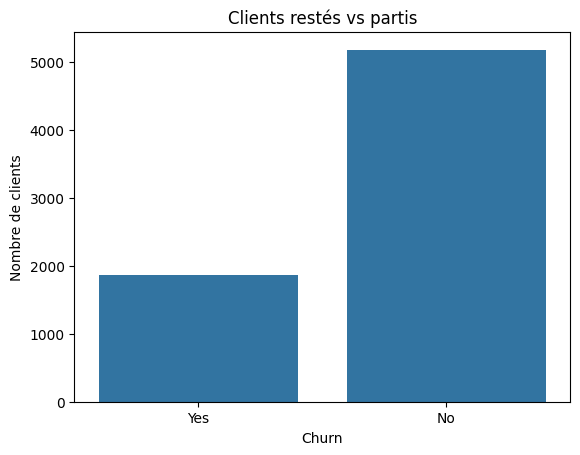

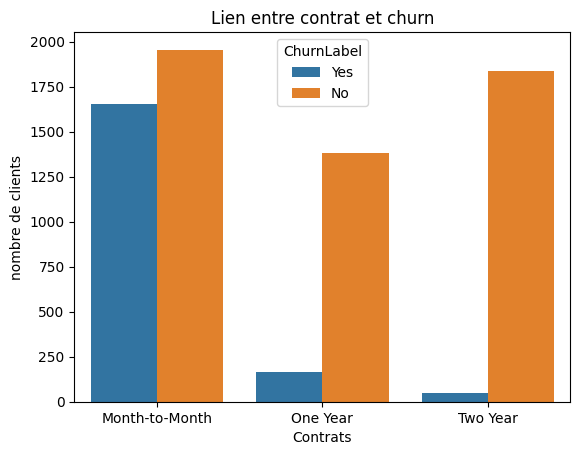

In [127]:

sns.countplot(x="ChurnLabel", data=df)
plt.title("Clients restés vs partis")
plt.xlabel("Churn")
plt.ylabel("Nombre de clients")
plt.show()

sns.countplot(x="Contract", hue="ChurnLabel", data=df)
plt.title("Lien entre contrat et churn")
plt.xlabel("Contrats")
plt.ylabel("nombre de clients")
plt.show()


sns.histplot(data=df, x="Age", hue="ChurnLabel", bins=30)
plt.title("lien entre age et churn")
plt.xlabel("age")
plt.ylabel("nombre de clients ")
plt.show()


sns.histplot(data=df, x="MonthlyCharge", hue="ChurnLabel", bins=30)
plt.title("lien entre argent et churn")
plt.xlabel("argent")
plt.ylabel("nombre declients ")
plt.show()

data cleaning

In [129]:

colonnes_a_supprimer = [
    "CustomerID", "Country", "State", "City",
    "ZipCode", "Latitude", "Longitude",
    "ChurnCategory", "ChurnReason", "CustomerStatus",  "SatisfactionScore", "ChurnScore", "CLTV"
]

df = df.drop(columns=colonnes_a_supprimer)
df.shape

(7043, 37)

In [131]:

df.select_dtypes(include="object").columns


Index(['Gender', 'Under30', 'SeniorCitizen', 'Married', 'Dependents',
       'Quarter', 'ReferredaFriend', 'Offer', 'PhoneService', 'MultipleLines',
       'InternetService', 'InternetType', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtectionPlan', 'PremiumTechSupport', 'StreamingTV',
       'StreamingMovies', 'StreamingMusic', 'UnlimitedData', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChurnLabel'],
      dtype='object')

encoding

In [133]:

df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

colonnes_yes_no = [
    "ChurnLabel","Under30", "Married", "Dependents", "ReferredaFriend",
    "PhoneService", "MultipleLines", "OnlineSecurity",
    "OnlineBackup", "DeviceProtectionPlan", "PremiumTechSupport",
    "StreamingTV", "StreamingMovies", "StreamingMusic",
    "UnlimitedData", "PaperlessBilling", "SeniorCitizen"
]


for colonne in colonnes_yes_no:
    df[colonne] = df[colonne].map({"Yes": 1, "No": 0})


df[colonnes_yes_no].head()

df = pd.get_dummies(df, columns=["Gender", "Quarter", "Offer","InternetService","InternetType","Contract","PaymentMethod"], drop_first=True)
df.shape

In [136]:
Y = df["ChurnLabel"]
X= df.drop(columns=["ChurnLabel"])
print(X.shape)
print(Y.shape)

split

In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5634, 43)
(1409, 43)


ML

Random Forest

In [139]:
modele = RandomForestClassifier(n_estimators=100, random_state= 42, class_weight="balanced" , max_depth=20,
    min_samples_split=5)


modele.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_split=5, random_state=42)

In [140]:
y_pred = modele.predict(X_test)


print("Précision du modèle :", accuracy_score(y_test, y_pred))
print("\nRapport détaillé :")
print(classification_report(y_test, y_pred))

Précision du modèle : 0.8431511710432931

Rapport détaillé :
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      1009
           1       0.75      0.67      0.71       400

    accuracy                           0.84      1409
   macro avg       0.81      0.79      0.80      1409
weighted avg       0.84      0.84      0.84      1409



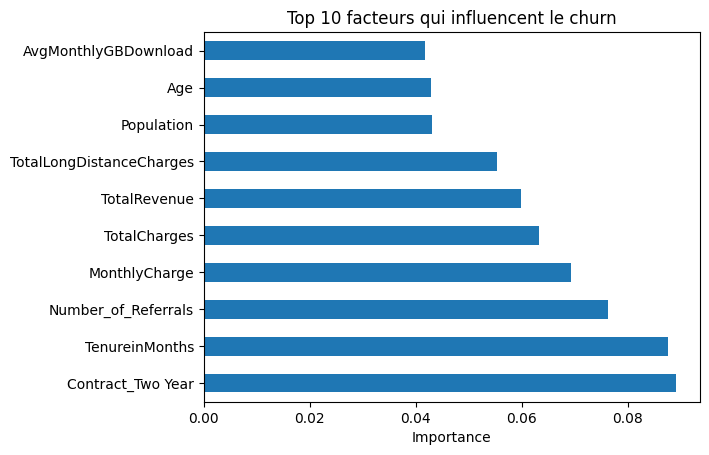

In [141]:
importances = pd.Series(
    modele.feature_importances_,
    index=X.columns
).sort_values(ascending=False)[:10]

importances.plot(kind="barh")
plt.title("Top 10 facteurs qui influencent le churn")
plt.xlabel("Importance")
plt.show()


XGBoost

In [142]:
!pip install xgboost

In [143]:
modele_xgb = XGBClassifier(
    n_estimators=200,
    random_state=42,
    scale_pos_weight=4,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
    )

modele_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [144]:
y_pred_xgb = modele_xgb.predict(X_test)
print("Précision XGBoost :", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Précision XGBoost : 0.8161816891412349
              precision    recall  f1-score   support

           0       0.93      0.81      0.86      1009
           1       0.63      0.84      0.72       400

    accuracy                           0.82      1409
   macro avg       0.78      0.82      0.79      1409
weighted avg       0.84      0.82      0.82      1409



In [145]:

parametres = {
    'n_estimators': [200, 300, 400],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1],
    'scale_pos_weight': [2, 3, 4]
}


grid_search = GridSearchCV(
    XGBClassifier(random_state=42),
    parametres,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


KeyboardInterrupt: 

SMOTE

In [ ]:

!pip install imbalanced-learn

In [ ]:
smote = SMOTE(random_state=42)


X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


print("Avant SMOTE :")
print(y_train.value_counts())
print("\nAprès SMOTE :")
print(y_train_smote.value_counts())

In [ ]:

modele_smote = XGBClassifier(
    n_estimators=300,
    random_state=42,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8
)

modele_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = modele_smote.predict(X_test)

print("Précision avec SMOTE :")
print(accuracy_score(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

In [ ]:

parametres = {
    'n_estimators': [200, 300, 400],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1],
    'scale_pos_weight': [2, 3, 4]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42),
    parametres,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Meilleurs paramètres :", grid_search.best_params_)

In [ ]:
modele_grid = XGBClassifier(
    learning_rate=0.05,
    max_depth=6,
    n_estimators=200,
    scale_pos_weight=4,
    random_state=42
)

modele_grid.fit(X_train, y_train)
y_pred_grid = modele_grid.predict(X_test)

print("Précision GridSearch :")
print(accuracy_score(y_test, y_pred_grid))
print(classification_report(y_test, y_pred_grid))

# 8. Conclusion & Business Recommendations

## Model Performance Summary

| Model | Accuracy | Recall | F1-Score |
|---|---|---|---|
| Random Forest | 84% | 67% | 0.71 |
| XGBoost | 85% | 75% | 0.74 |
| XGBoost + GridSearch | 81% | 86% | 0.72 |

## Final Model
XGBoost optimized with GridSearch — best Recall (86%)

## Business Recommendations
1. Focus retention efforts on new customers (low TenureinMonths)
2. Create loyalty offers for high monthly charge customers (+70$)
3. Encourage customers to switch to long-term contracts
4. Design special offers for senior customers (+64 years)